# Análise de Resultados (a partir de 19/05/2026)

Este notebook foca nos experimentos realizados a partir do dia 19 de maio de 2026, lendo do arquivo `model_results.csv`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

sns.set_theme(style="whitegrid")

In [2]:
def load_results_from_csv(file_path, date_cutoff='2026-05-19'):
    """
    Carrega resultados do model_results.csv a partir de uma data de corte.
    Filtra apenas linhas com phase='test' e remove duplicatas.
    """
    df = pd.read_csv(file_path, sep=';')
    
    # Converter timestamp para datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Filtrar a partir da data de corte
    cutoff = pd.Timestamp(date_cutoff)
    df = df[df['timestamp'] >= cutoff]
    
    # Filtrar apenas fase de teste (não tuning_cv)
    df = df[df['phase'] == 'test']
    
    # Remover duplicatas (manter a mais recente por modelo/cenário/smote)
    df = df.sort_values('timestamp')
    df = df.drop_duplicates(subset=['model', 'scenario', 'smote'], keep='last')
    
    # Converter smote para bool
    df['smote'] = df['smote'].astype(str).str.lower().map({'true': True, 'false': False})
    
    # Garantir que as métricas são numéricas
    for col in ['roc_auc', 'f1', 'accuracy']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df.reset_index(drop=True)


df = load_results_from_csv('model_results.csv')
df = df.sort_values('timestamp')

print(f"Total de experimentos (teste) desde 19/05: {len(df)}")
print(f"Modelos: {df['model'].unique().tolist()}")
print(f"Cenários: {df['scenario'].unique().tolist()}")
df.head(10)

Total de experimentos (teste) desde 19/05: 36
Modelos: ['DecisionTree', 'KNN', 'LogisticRegression', 'RandomForest', 'SVM', 'XGBoost']
Cenários: ['sem_submodalidade', 'submodalidade_agrupada', 'submodalidade_engineered']


,model,scenario,smote,phase,roc_auc,f1,accuracy,best_params,timestamp
0,DecisionTree,sem_submodalidade,True,test,0.907896,0.831701,0.817412,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 22:56:57.829911
1,DecisionTree,sem_submodalidade,False,test,0.910683,0.854567,0.830973,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 22:56:59.405336
2,DecisionTree,submodalidade_agrupada,True,test,0.918547,0.850267,0.832962,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 23:10:05.422844
3,DecisionTree,submodalidade_agrupada,False,test,0.922099,0.870189,0.845172,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 23:10:07.120320
4,DecisionTree,submodalidade_engineered,True,test,0.907896,0.831701,0.817412,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 23:20:31.466166
5,DecisionTree,submodalidade_engineered,False,test,0.910683,0.854567,0.830973,"{'dt__criterion': 'entropy', 'dt__max_depth': ...",2026-05-19 23:20:33.042022
6,KNN,sem_submodalidade,True,test,0.814885,0.769677,0.737708,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",2026-05-20 06:58:51.386397
7,KNN,sem_submodalidade,False,test,0.823874,0.791512,0.746979,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",2026-05-20 07:00:04.347483
8,KNN,submodalidade_agrupada,True,test,0.859079,0.800400,0.774211,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",2026-05-20 07:37:14.366454
9,KNN,submodalidade_agrupada,False,test,0.867868,0.823255,0.785928,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",2026-05-20 07:39:10.837609


## Melhores Resultados por Métrica

In [3]:
metrics = ['roc_auc', 'f1', 'accuracy']
for metric in metrics:
    if not df[metric].dropna().empty:
        best = df.loc[df[metric].idxmax()]
        print(f"Melhor {metric.upper()}: {best[metric]:.4f} | Modelo: {best['model']} | Cenário: {best['scenario']} | SMOTE: {best['smote']}")

Melhor ROC_AUC: 0.9446 | Modelo: RandomForest | Cenário: submodalidade_agrupada | SMOTE: False
Melhor F1: 0.8869 | Modelo: RandomForest | Cenário: submodalidade_agrupada | SMOTE: False
Melhor ACCURACY: 0.8681 | Modelo: RandomForest | Cenário: submodalidade_agrupada | SMOTE: False


## Comparação de Modelos (ROC AUC por Modelo e SMOTE)

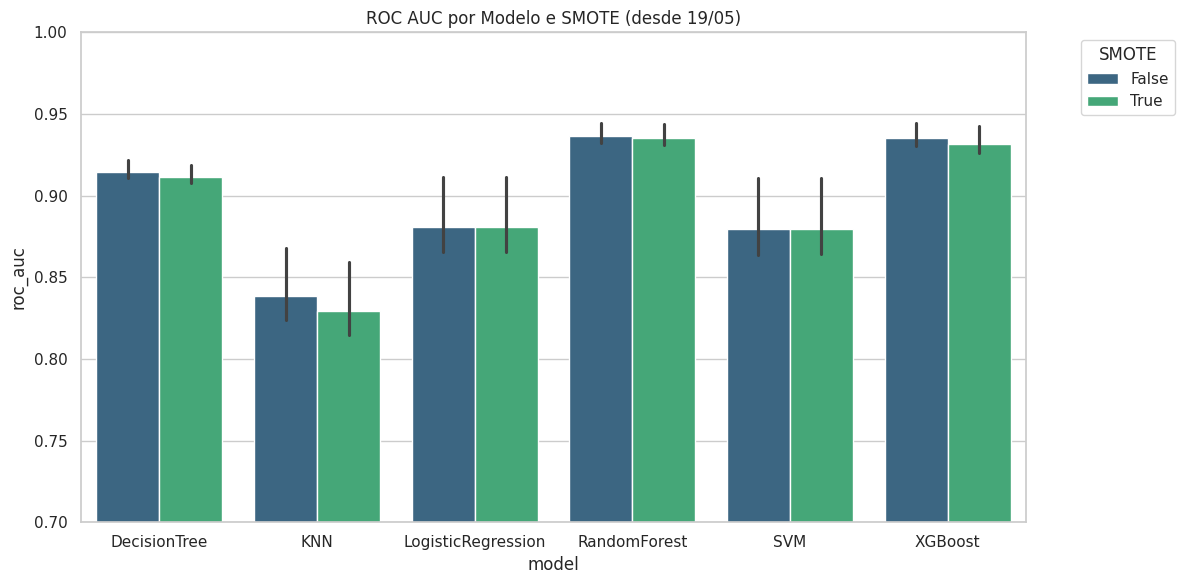

In [4]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='model', y='roc_auc', hue='smote', palette='viridis')
plt.title('ROC AUC por Modelo e SMOTE (desde 19/05)')
plt.ylim(0.7, 1.0)
plt.legend(title='SMOTE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Distribuição de ROC AUC por Cenário

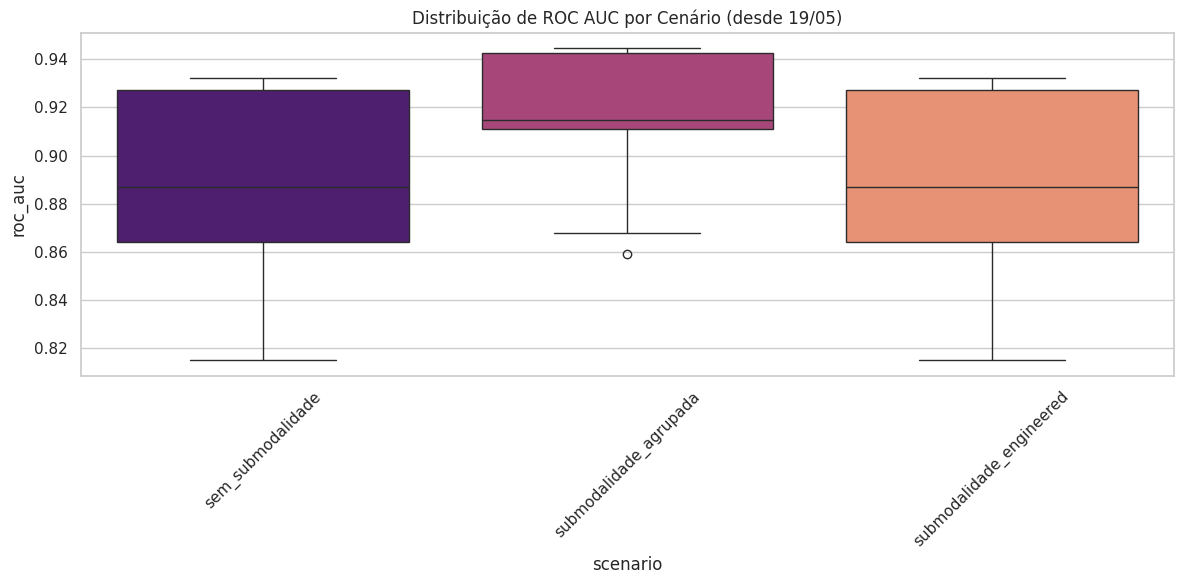

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='scenario', y='roc_auc', palette='magma', hue='scenario', legend=False)
plt.title('Distribuição de ROC AUC por Cenário (desde 19/05)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Heatmap: ROC AUC por Modelo e Cenário

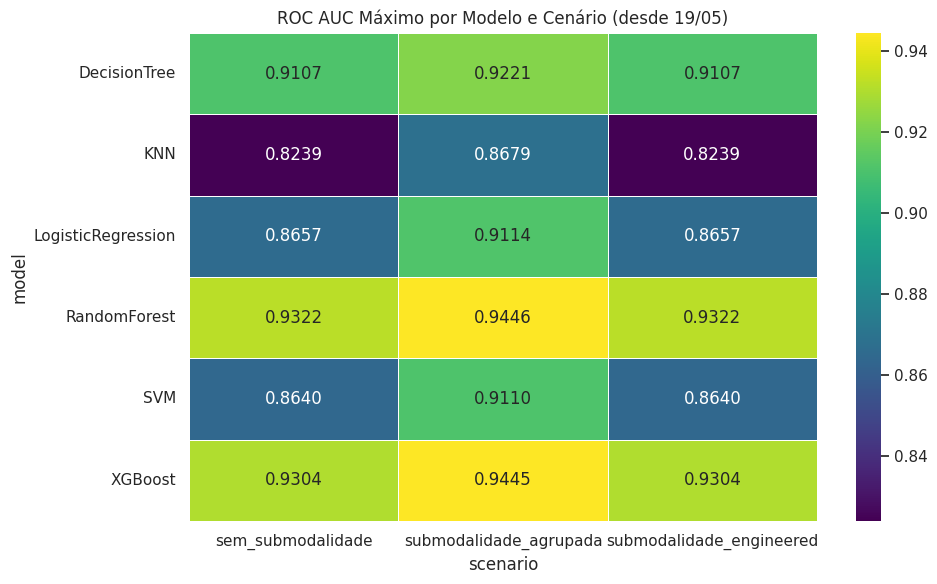

In [6]:
pivot = df.groupby(['model', 'scenario'])['roc_auc'].max().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis', linewidths=0.5)
plt.title('ROC AUC Máximo por Modelo e Cenário (desde 19/05)')
plt.tight_layout()
plt.show()

## Comparação de Todas as Métricas por Modelo

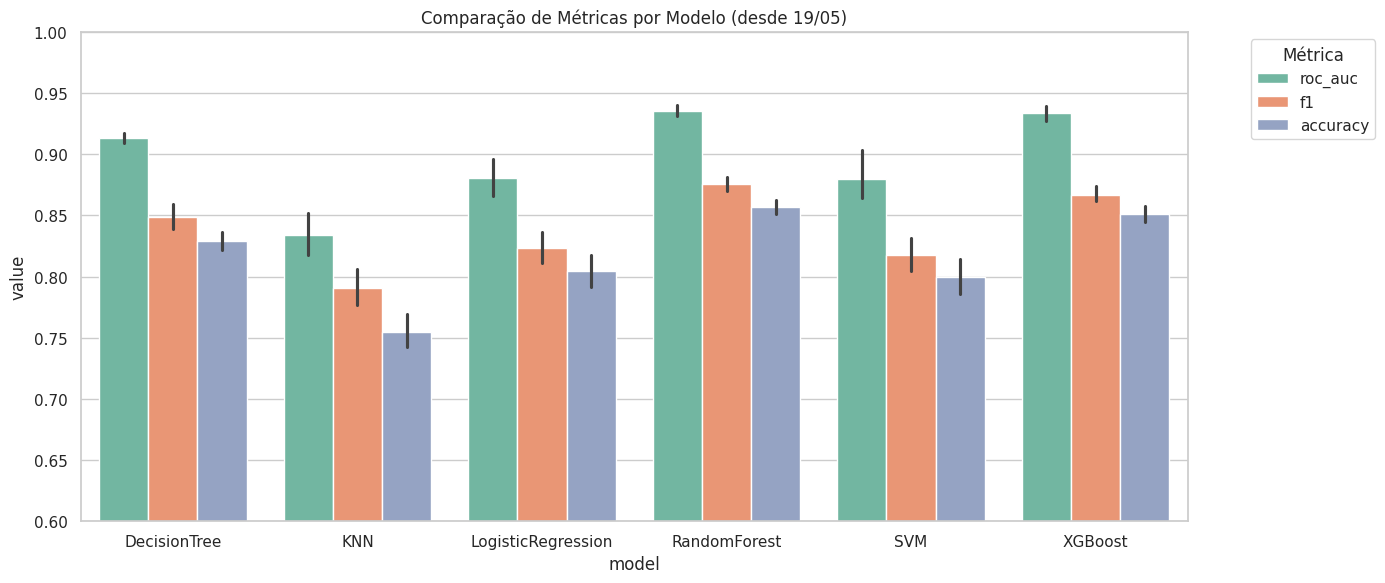

In [7]:
df_melted = df.melt(
    id_vars=['model', 'scenario', 'smote'],
    value_vars=['roc_auc', 'f1', 'accuracy'],
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='model', y='value', hue='metric', palette='Set2')
plt.title('Comparação de Métricas por Modelo (desde 19/05)')
plt.ylim(0.6, 1.0)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Tabela Completa de Resultados (Estilizada)

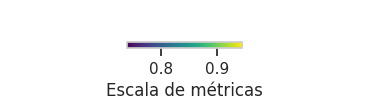

,model,scenario,smote,roc_auc,f1,accuracy,timestamp
0,RandomForest,submodalidade_agrupada,False,0.9446,0.8869,0.8681,2026-05-20 20:37:18.785242
1,XGBoost,submodalidade_agrupada,False,0.9445,0.8802,0.8644,2026-05-20 21:52:47.060061
2,RandomForest,submodalidade_agrupada,True,0.9436,0.8841,0.8670,2026-05-20 20:37:10.896473
3,XGBoost,submodalidade_agrupada,True,0.9425,0.8758,0.8607,2026-05-20 21:52:44.153687
4,RandomForest,submodalidade_engineered,False,0.9322,0.8741,0.8537,2026-05-20 20:45:31.107851
5,RandomForest,sem_submodalidade,False,0.9322,0.8741,0.8537,2026-05-20 20:28:40.414552
6,RandomForest,submodalidade_engineered,True,0.9308,0.8684,0.8502,2026-05-20 20:45:23.402213
7,RandomForest,sem_submodalidade,True,0.9308,0.8684,0.8502,2026-05-20 20:28:32.786801
8,XGBoost,sem_submodalidade,False,0.9304,0.8648,0.8482,2026-05-20 21:42:47.739258
9,XGBoost,submodalidade_engineered,False,0.9304,0.8648,0.8482,2026-05-20 22:00:50.753945


In [8]:
cols_display = ['model', 'scenario', 'smote', 'roc_auc', 'f1', 'accuracy', 'timestamp']
df_display = df[cols_display].sort_values('roc_auc', ascending=False).reset_index(drop=True)

# Colormap por coluna de métrica
color_cols = ['roc_auc', 'f1', 'accuracy']
n_cols = len(color_cols)
fig, ax = plt.subplots(figsize=(1.5 * n_cols, 0.5))
fig.patch.set_visible(False)
ax.axis('off')
cb = plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=df[color_cols].min().min(),
                                                     vmax=df[color_cols].max().max()),
                          cmap='viridis'),
    ax=ax, orientation='horizontal'
)
cb.set_label('Escala de métricas')
plt.show()

styled = (
    df_display
    .style
    .background_gradient(subset=color_cols, cmap='viridis')
    .format({c: '{:.4f}' for c in color_cols})
)
styled

## Resumo por Cenário

In [9]:
summary = df.groupby('scenario')[['roc_auc', 'f1', 'accuracy']].agg(['mean', 'max', 'min']).round(4)
print(summary.to_string())

                         roc_auc                      f1                 accuracy                
                            mean     max     min    mean     max     min     mean     max     min
scenario                                                                                         
sem_submodalidade         0.8863  0.9322  0.8149  0.8286  0.8741  0.7697   0.8068  0.8537  0.7377
submodalidade_agrupada    0.9156  0.9446  0.8591  0.8548  0.8869  0.8004   0.8346  0.8681  0.7742
submodalidade_engineered  0.8863  0.9322  0.8149  0.8286  0.8741  0.7697   0.8068  0.8537  0.7377


## Impacto do SMOTE

Média por uso de SMOTE:
       roc_auc      f1  accuracy
smote                           
False   0.8975  0.8417    0.8186
True    0.8947  0.8329    0.8136


/tmp/ipykernel_9150/1981253900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smote', y=metric, palette='coolwarm', ax=ax)
/tmp/ipykernel_9150/1981253900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smote', y=metric, palette='coolwarm', ax=ax)
/tmp/ipykernel_9150/1981253900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smote', y=metric, palette='coolwarm', ax=ax)


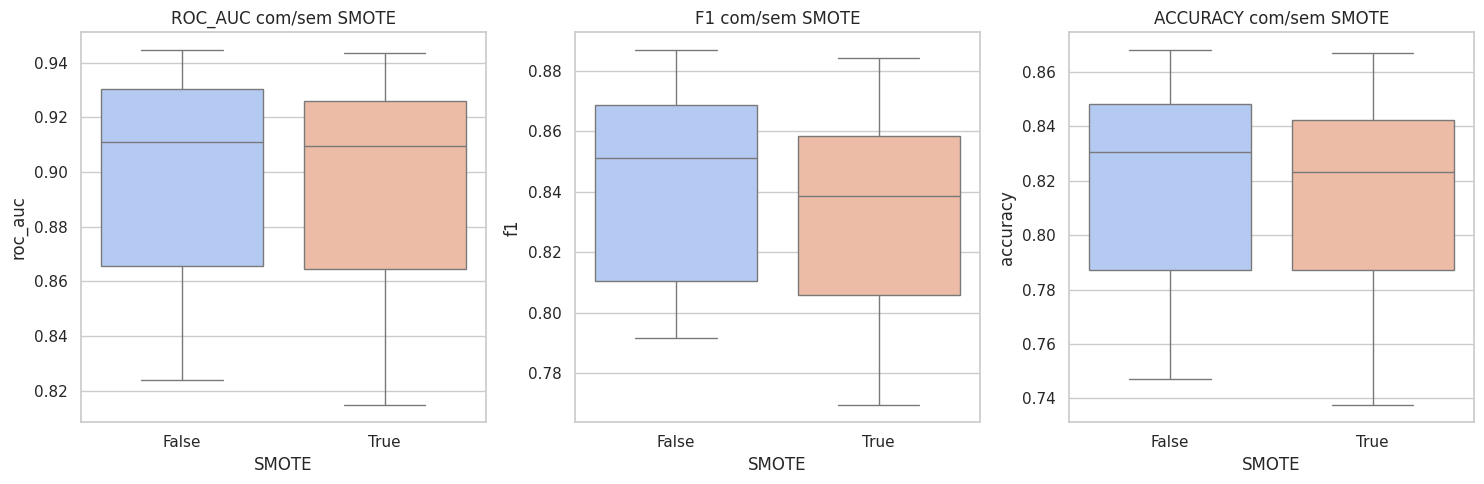

In [10]:
smote_summary = df.groupby('smote')[['roc_auc', 'f1', 'accuracy']].mean().round(4)
print("Média por uso de SMOTE:")
print(smote_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['roc_auc', 'f1', 'accuracy']):
    sns.boxplot(data=df, x='smote', y=metric, palette='coolwarm', ax=ax)
    ax.set_title(f'{metric.upper()} com/sem SMOTE')
    ax.set_xlabel('SMOTE')
plt.tight_layout()
plt.show()